In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

In [157]:
train_data: pd.DataFrame = pd.read_csv("data/train.csv")
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [158]:
test_data: pd.DataFrame = pd.read_csv("data/test.csv")
test_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


## Columns, Shape

In [159]:
print("### TRAIN ###")
print(train_data.columns)
print(train_data.shape)
print("\n")
print("### TEST ###")
print(test_data.columns)
print(test_data.shape)

### TRAIN ###
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')
(8693, 14)


### TEST ###
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')
(4277, 13)


## Info

In [160]:
print("### TRAIN ###")
train_data.info()
print("\n")
print("### TEST ###")
test_data.info()

### TRAIN ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


### TEST ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   C

## Describe

In [161]:
print("### TRAIN ###")
print(train_data.describe())
print("\n")
print("### TEST ###")
print(test_data.describe())

### TRAIN ###
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  


### TEST ###
               Age   RoomService     FoodCourt  ShoppingMall          

## NaN

In [162]:
print("### TRAIN ### \n")
print(f"Number of NaN: {train_data.isna().any(axis=1).sum()}")
print(f"Percentage of NaN {100*train_data.isna().any(axis=1).sum()/len(train_data):.2f}%")
print(100*train_data.isna().sum()/len(train_data))
print(train_data.isna().sum(axis=1).value_counts().sort_index())

print("\n ### TEST ### ")
print(f"Number of NaN: {test_data.isna().any(axis=1).sum()}")
print(f"Percentage of NaN {100*test_data.isna().any(axis=1).sum()/len(test_data):.2f}%")
print(100*test_data.isna().sum()/len(test_data))
print(test_data.isna().sum(axis=1).value_counts().sort_index())

### TRAIN ### 

Number of NaN: 2087
Percentage of NaN 24.01%
PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64
0    6606
1    1867
2     203
3      17
Name: count, dtype: int64

 ### TEST ### 
Number of NaN: 996
Percentage of NaN 23.29%
PassengerId     0.000000
HomePlanet      2.034136
CryoSleep       2.174421
Cabin           2.338087
Destination     2.151040
Age             2.127660
VIP             2.174421
RoomService     1.917232
FoodCourt       2.478373
ShoppingMall    2.291326
Spa             2.361468
VRDeck          1.870470
Name            2.197802
dtype: float64
0    3281
1     879
2     113
3       4
Name: count, dtype: int64


## Features

### PassengerId

In [163]:
group = train_data["PassengerId"].str.split("_").str[0]
assert len(group) == train_data["PassengerId"].nunique(), "IDs are not unique"
print(f"Total number of passengers (IDs): {len(group)}")
print(f"Number of unique groups: {group.nunique()}")
print(f"Average number of people per group: {len(group)/group.nunique():.3f}")


Total number of passengers (IDs): 8693
Number of unique groups: 6217
Average number of people per group: 1.398


### HomePlanet

In [164]:
homeplanet = train_data["HomePlanet"]
print(f"Total number of unique home planets: {homeplanet.nunique()}")
print(f"Number of NaN: {homeplanet.isna().sum()} ({100*homeplanet.isna().sum()/len(homeplanet):.1f}%)")
print(homeplanet.value_counts())

Total number of unique home planets: 3
Number of NaN: 201 (2.3%)
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64


### CryoSleep

In [165]:
cryosleep = train_data["CryoSleep"]
print(f"Number of positive {cryosleep.sum()} ({100*cryosleep.sum()/len(cryosleep):.2f}%)")
print(f"Number of NaN: {cryosleep.isna().sum()} ({100*cryosleep.isna().sum()/len(cryosleep):.1f}%)")
print(cryosleep.value_counts())

Number of positive 3037 (34.94%)
Number of NaN: 217 (2.5%)
CryoSleep
False    5439
True     3037
Name: count, dtype: int64


### Cabin

In [166]:
cabin = train_data["Cabin"]
cabin_deck = train_data["Cabin"].str.split("/").str[0]
cabin_number = train_data["Cabin"].str.split("/").str[1]
cabin_side = train_data["Cabin"].str.split("/").str[2]
print(f"Total number of unique cabin decks: {cabin_deck.nunique()}")
print(f"Number of NaN: {cabin.isna().sum()} ({100*cabin.isna().sum()/len(cabin):.1f}%)")

print("Cabin decks:", cabin_deck.unique())
print("Cabin number:", cabin_number.unique())
print("Cabin side:", cabin_side.unique())

print(cabin_deck.value_counts())
print(cabin_side.value_counts())


Total number of unique cabin decks: 8
Number of NaN: 199 (2.3%)
Cabin decks: ['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']
Cabin number: ['0' '1' '2' ... '1892' '1893' '1894']
Cabin side: ['P' 'S' nan]
Cabin
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64
Cabin
S    4288
P    4206
Name: count, dtype: int64


### Destination

In [167]:
destination = train_data["Destination"]
print(f"Total number of unique home planets: {destination.nunique()}")
print(f"Number of NaN: {destination.isna().sum()} ({100*destination.isna().sum()/len(destination):.1f}%)")
print(destination.value_counts())

Total number of unique home planets: 3
Number of NaN: 182 (2.1%)
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64


### Age

Number of NaN: 179 (2.1%)
Number with age = 0: 178
count    8514.000000
mean       28.827930
std        14.489021
min         0.000000
25%        19.000000
50%        27.000000
75%        38.000000
max        79.000000
Name: Age, dtype: float64


<Axes: >

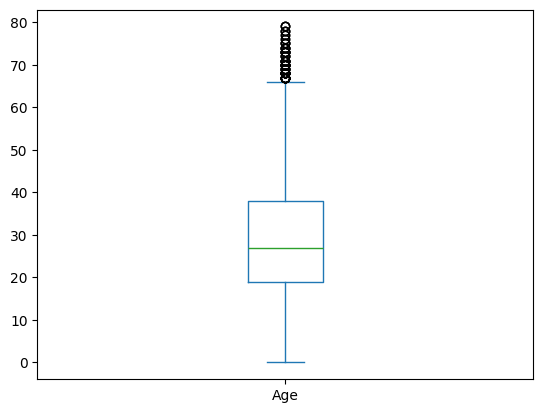

In [168]:
age = train_data["Age"]
print(f"Number of NaN: {age.isna().sum()} ({100*age.isna().sum()/len(age):.1f}%)")
print(f"Number with age = 0: {(age == 0).sum()}")
print(age.describe())
age.plot(kind="box")

### VIP

In [169]:
vip = train_data["VIP"]
print(vip.unique())
print(f"Number of positive {vip.sum()} ({100*vip.sum()/len(vip):.2f}%)")
print(f"Number of NaN: {vip.isna().sum()} ({100*vip.isna().sum()/len(vip):.1f}%)")

[False True nan]
Number of positive 199 (2.29%)
Number of NaN: 203 (2.3%)


### RoomService, FoodCourt, ShoppingMall, Spa, VRDeck

        RoomService     FoodCourt  ShoppingMall           Spa        VRDeck
count   8512.000000   8510.000000   8485.000000   8510.000000   8505.000000
mean     224.687617    458.077203    173.729169    311.138778    304.854791
std      666.717663   1611.489240    604.696458   1136.705535   1145.717189
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000      0.000000      0.000000
50%        0.000000      0.000000      0.000000      0.000000      0.000000
75%       47.000000     76.000000     27.000000     59.000000     46.000000
max    14327.000000  29813.000000  23492.000000  22408.000000  24133.000000


count     8693.000000
mean      1440.866329
std       2803.045694
min          0.000000
25%          0.000000
50%        716.000000
75%       1441.000000
max      35987.000000
dtype: float64
Number of people who did not pay anything: 3653 (42.02%)
1.5IQR = 2161.50


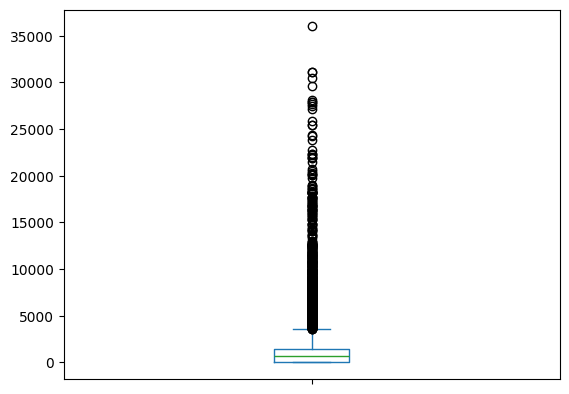

In [173]:

bills = train_data[["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]]
print(bills.describe())

print("\n")
sum_bills = bills.sum(axis=1)
print(sum_bills.describe())
print(f"Number of people who did not pay anything: {(sum_bills == 0).sum()} ({100*(sum_bills == 0).sum()/len(sum_bills):.2f}%)")
sum_bills.plot(kind="box")
IQR = sum_bills.quantile(0.75) - sum_bills.quantile(0.25)
print(f"1.5IQR = {1.5*IQR:.2f}")

### Name

In [171]:
name = train_data["Name"]
first_name = train_data["Name"].str.split(" ").str[0]
last_name = train_data["Name"].str.split(" ").str[1]
print(f"Number of unique last names: {last_name.nunique()}")
print(f"Average people per family: {len(name)/last_name.nunique():.2f}")
print(f"Number of NaN: {name.isna().sum()} ({100*name.isna().sum()/len(name):.1f}%)")

Number of unique last names: 2217
Average people per family: 3.92
Number of NaN: 200 (2.3%)


### Transported

In [172]:
transported = train_data["Transported"]
print(transported.unique())
print(f"Number of positive {transported.sum()} ({100*transported.sum()/len(transported):.2f}%)")
print(f"Number of NaN: {transported.isna().sum()} ({100*transported.isna().sum()/len(transported):.1f}%)")

[False  True]
Number of positive 4378 (50.36%)
Number of NaN: 0 (0.0%)


## Summary

### shape
- train: 8693 x 14
- test: 4277 x 13

### columns
- Same columns

### info

features:
- boolean: CryoSleep, VIP, Transported (target)
- int/float: Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck
- object/string: PassengerId, HomePlanet, Cabin, Destination, Name

### Specific features

- PasseengerId: `gggg_pp` where `gggg` is their group and `pp` number within group. I think using the group that is useful as people traveling in group have a high correlation of surviving as they will statistically be located closer to each other given the time of the accident
- HomePlanet: 3 unique planets, categorical encoding
- CryoSleep: boolean value, some NaN values present. Encode as 0-1
- Cabin: keep cabin deck (8 unique values) and cabin side (2 unique values) for training but discard cabin number (1817 unique values)
- Destination: 3 unique destination, categorical encoding
- Age: Some age values = 0, but could be babies instead of wrong format. Some values above 1.5IQR could be removed as noise but they make sense as they are reasonalbe human ages
- VIP: boolean value, some NaN values present. Encode as 0-1
- RoomService, FoodCourt, ShoppingMall, Spa, VRDeck: Can be combined into a single feature call "bills". NaN values present but can be set to 0.0. Alternatively created into a binary feature where we divide people who have paid anything versus not (either for each individual bill or the total).
- Name: Keep last name as we get another form of group information. About 2217 unique last name. Could alternative give a "family size" feature where we assign size based on groupby(last_name)
- Transported: Target variable, no NaN, around 50% for positive class and 50% for negative class, meaning no stratification needed for training.
